In [3]:
import numpy as np
import pandas as pd

###`Q-1:` Write a program to create an empty series.

In [8]:
# code here
series_empty=pd.Series([])
series_empty

Series([], dtype: object)

###`Q-2:` Write a Pandas program to add, subtract, multiple and divide two Pandas Series.

In [14]:
marks1 = {"maths": "80", "Science": "90"}
marks2 = {"maths": "84", "Science": "10"}

series1 = pd.Series(marks1).astype(int)
series2 = pd.Series(marks2).astype(int)

# Perform arithmetic operations
addition = series1 + series2
subtraction = series1 - series2
multiplication = series1 * series2
division = series1 / series2

print("Addition:\n", addition)
print("\nSubtraction:\n", subtraction)
print("\nMultiplication:\n", multiplication)
print("\nDivision:\n", division)


Addition:
 maths      164
Science    100
dtype: int64

Subtraction:
 maths      -4
Science    80
dtype: int64

Multiplication:
 maths      6720
Science     900
dtype: int64

Division:
 maths      0.952381
Science    9.000000
dtype: float64


###`Q-3` Write a Pandas program to compare the elements of the two Pandas Series.
Sample Series: [2, 4, 6, 8, 10], [1, 3, 5, 7, 10]



In [15]:
print("Equal\n",series1==series2)
print("Greater\n",series1>series2)
print("Smaller\n",series1<series2)
print("Greater or Equal\n",series1>=series2)
print("Smaller or Equal\n",series1>=series2)

Equal
 maths      False
Science    False
dtype: bool
Greater
 maths      False
Science     True
dtype: bool
Smaller
 maths       True
Science    False
dtype: bool
Greater or Equal
 maths      False
Science     True
dtype: bool
Smaller or Equal
 maths      False
Science     True
dtype: bool


###`Q-5.`Write a function to change the data type of given a column or a Series. Function takes series and data type as input, returns the converted series.
```
series = pd.Series([1,2,'Python', 2.0, True, 100])
change to float type data
```
Note: Read about pd.to_numeric()

In [21]:
# code here
series = pd.Series([1, 2, 'Python', 2.0, True, 100])

# Function to change the data type of a Series
def change_dtype(series, dtype):
    # For numeric conversions, it's safer to use pd.to_numeric
    if dtype == 'float' or dtype == 'int':
        return pd.to_numeric(series, errors='coerce')  # invalid values become NaN
    else:
        return series.astype(dtype)

# Convert to float
converted_series = change_dtype(series, 'str')
print(converted_series)

0         1
1         2
2    Python
3       2.0
4      True
5       100
dtype: object


Download data - https://drive.google.com/file/d/1LRhXwbEodeWXtzPhJCX0X9Lf_BECzvqb/view?usp=share_link
All Batsman runs series in IPL 2008 to 2022.

Below questions are based on this data.

###`Q-6` Find top 10 most run getter from the series.

In [44]:
# code here
ipl=pd.read_csv('task16_batsman_runs_series.csv',index_col="batter").squeeze('columns')
ipl.sort_values(ascending=False).head(10)

batter
V Kohli           6634
S Dhawan          6244
DA Warner         5883
RG Sharma         5881
SK Raina          5536
AB de Villiers    5181
CH Gayle          4997
MS Dhoni          4978
RV Uthappa        4954
KD Karthik        4377
Name: batsman_run, dtype: int64

###`Q-7` No of players having runs above 3000

In [49]:
# code here
ipl[ipl.values>3000].count()

np.int64(20)

###`Q-8` No of players having runs above mean value?

In [53]:
# code here
ipl[ipl.values>ipl.mean()].count()

np.int64(128)

Download data - https://drive.google.com/file/d/1QZuZ5bypUInfVvarHACLAi8tXXHvb8xd/view?usp=share_link

file name - items.csv



###`Q-9`
    i. Read `items.csv` making `item_name` as index.
    ii. Show no of nan values
    ii. Item price is given in $, so convert it to rupees without currency symbol.
    iii. Make data type of newly made series as float.
    iv. Fill nan with mean of the series


How csv file looks

```
item_name	item_price
Chips and Fresh Tomato Salsa	$2.39
Izze	$3.39
Nantucket Nectar	$3.39
Chips and Tomatillo-Green Chili Salsa	$2.39
Chicken Bowl	$16.98

```

In [66]:
# code here
import pandas as pd

# i. Read items.csv making item_name as index
df = pd.read_csv('items.csv', index_col='item_name')

# ii. Show number of NaN values
print("Number of NaN values before processing:")
print(df.isna().sum())

# iii. Convert price from $ to rupees (₹) without currency symbol
# Assuming $1 = ₹83.5 (you can adjust the rate)
df['item_price'] = df['item_price'].str.replace('$', '', regex=False).astype(float) * 83.5

# iv. Make data type of newly made series as float
df['item_price'] = df['item_price'].astype(float)

# v. Fill NaN values with mean of the series
df['item_price'].fillna(df['item_price'].mean(), inplace=True)

print("\nNumber of NaN values after filling:")
print(df.isna().sum())

print("\nFinal DataFrame:")
print(df)



Number of NaN values before processing:
item_price    50
dtype: int64

Number of NaN values after filling:
item_price    0
dtype: int64

Final DataFrame:
                                       item_price
item_name                                        
Chips and Fresh Tomato Salsa              199.565
Izze                                      283.065
Nantucket Nectar                          283.065
Chips and Tomatillo-Green Chili Salsa     199.565
Chicken Bowl                             1417.830
...                                           ...
Steak Burrito                             981.125
Steak Burrito                             981.125
Chicken Salad Bowl                        939.375
Chicken Salad Bowl                        730.625
Chicken Salad Bowl                        730.625

[4622 rows x 1 columns]


C:\Users\rajat\AppData\Local\Temp\ipykernel_12956\4273214750.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['item_price'].fillna(df['item_price'].mean(), inplace=True)


###`Q-10`:
    i. Find mean price
    ii. Find 30th and 6th percentile value
    iii. Plot Histogram on price with bin size 50
    iv. No of items price lies between [1000 to 2000]



C:\Users\rajat\AppData\Local\Temp\ipykernel_12956\2855267836.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['item_price'].fillna(df['item_price'].mean(), inplace=True)


Mean Price: 623.1631299212598
30th Percentile: 371.575
6th Percentile: 104.375


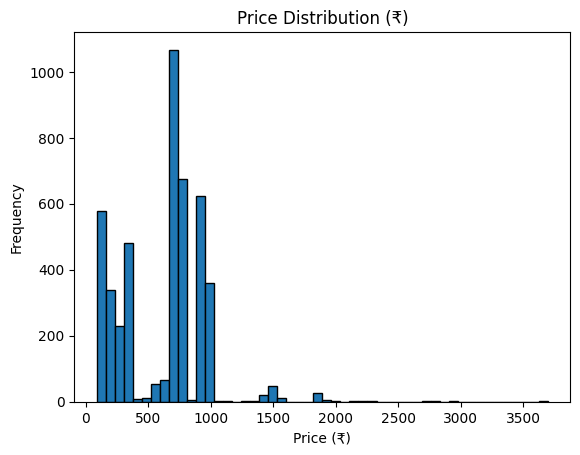

Items between ₹1000 and ₹2000: 116


In [68]:
import pandas as pd
import matplotlib.pyplot as plt

# Read CSV
df = pd.read_csv('items.csv', index_col='item_name')

# Clean price and convert $ → ₹
df['item_price'] = df['item_price'].str.replace('$', '', regex=False).astype(float) * 83.5

# Fill missing values with mean
df['item_price'].fillna(df['item_price'].mean(), inplace=True)

# i. Mean price
print("Mean Price:", df['item_price'].mean())

# ii. 30th and 6th percentile
print("30th Percentile:", df['item_price'].quantile(0.30))
print("6th Percentile:", df['item_price'].quantile(0.06))

# iii. Histogram with 50 bins
df['item_price'].plot(kind='hist', bins=50, edgecolor='black', title='Price Distribution (₹)')
plt.xlabel('Price (₹)')
plt.show()

# iv. Count of items priced between 1000 and 2000
count = df[(df['item_price'] >= 1000) & (df['item_price'] <= 2000)].shape[0]
print("Items between ₹1000 and ₹2000:", count)
